# Replicating Iskhakov & Keane (2021) with `dcegm`

This notebook builds the life-cycle labor supply model from
Iskhakov, F. & Keane, M. (2021), *"Effects of Taxes and Safety Net Pensions
on Life-Cycle Labor Supply, Savings and Human Capital: The Case of
Australia"*, Journal of Econometrics, using `dcegm`. It is a good first
replication example for these docs because the package's continuous
experience state was built with this paper in mind (see
[Limitations](../background/limitations.rst)).

**Scope.** This is a *calibrated structural replication*, not a re-estimation:

- We plug in the paper's **published point estimates** (Tables 5-7 of the
  supplementary material) rather than re-running the method-of-simulated-moments
  estimation on HILDA, which is restricted-access microdata we don't have.
- We fix the **post-2010 Age Pension regime** throughout, rather than tracking
  the calendar-time policy changes the paper's estimation sample (2001-2016)
  passed through. This makes the model a clean stationary life cycle for one
  cohort, consistent with how the paper itself fixes a policy regime for its
  own counterfactual simulations (Section 9).
- We truncate the horizon at the **compulsory retirement age of 85** instead
  of 100, and treat the terminal state (age 85, or an earlier death) as
  bequeathing all remaining wealth. dcegm's terminal-period solver assumes
  consumption equals full wealth, so it cannot reproduce the paper's genuine
  consumption/bequest trade-off in the true final period (eq. 21-22); this is
  a minor difference for the mechanism we're illustrating.

The goal is to reproduce the paper's *mechanism* (kinked policy functions
from combining a discrete hours choice with a continuous savings choice,
under taxes/means-tested pensions/superannuation/mortality risk) and its
*qualitative* life-cycle and policy-experiment implications — not to
match its estimated moments point for point.


In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import dcegm

jax.config.update("jax_enable_x64", True)

## 1. Calibration

Hours are discrete, $H = \{0, 1000, 2000, 2250, 2500, 3000\}$ (eq. 1). All
monetary values are in \$1000 AUD, matching the paper.

The dictionaries below transcribe Tables 5 (preferences), 6 (human capital)
and 7 (misc.) of the supplementary material, plus the tax function (eq. 27
of the main paper) and the pension and survival functions (eqs. 2-3 of the
supplement). Discount factor, human-capital constants and the high-type
wage premium differ by education, so `build_params`/`build_model_specs`
assemble one calibration per education group.


In [2]:
# Hours levels H = {0, 1000, 2000, 2250, 2500, 3000}, choice index 0..5
HOURS_BY_CHOICE = jnp.array([0.0, 1000.0, 2000.0, 2250.0, 2500.0, 3000.0])

EDUCATION_GROUPS = ["dropout", "highschool", "college"]
T0_BY_EDUCATION = {"dropout": 19, "highschool": 19, "college": 23}
T_RETIRE = 85  # compulsory retirement age (last period agents may work)

# --- Table 5: preference parameters ---
PREFERENCE_PARAMS = {
    "zeta": 0.79488,  # CRRA coefficient in consumption
    "gamma": jnp.array(
        [0.0, 1.4139, 2.0088, 2.9213, 2.8639, 3.8775]
    ),  # disutility by hours level (gamma_0=0)
    "kappa_1": 0.50321,  # low-type disutility correction
    "kappa_2": 0.00008,  # quadratic age term (older workers)
    "kappa_3": 0.05083,  # linear age term (younger workers)
    "xi": 0.48834,  # CRRA coefficient of bequest
    "b_scale": 0.68659,  # bequest scale
    "beta": {"dropout": 0.96806, "highschool": 0.96732, "college": 0.96963},
    "taste_shock_scale": 0.29950,  # lambda
}

# --- Table 6: human capital production function, eq. (4) ---
HUMAN_CAPITAL_PARAMS = {
    "eta0_edu": {"dropout": 2.45647, "highschool": 2.56761, "college": 2.78766},
    "eta0_high_type": 0.39311,
    "eta1_edu": {"dropout": 0.01974, "highschool": 0.02164, "college": 0.03041},
    "eta2_edu": {"dropout": 0.00000, "highschool": -0.00002, "college": -0.00017},
    "eta3": 0.02676,
    "eta4": -0.00076,
}

# --- Table 7: misc structural parameters ---
MISC_PARAMS = {
    "sigma0": 0.24485,  # wage shock std: constant
    "sigma1": 0.00421,  # wage shock std: age slope
    "tr": 5.51308,  # parental transfer ($1000/year, up to age 23)
    "rho_super": {"dropout": 6.47838, "highschool": 5.43473, "college": 6.30347},
    "high_type_share": {"dropout": 0.69306, "highschool": 0.80130, "college": 0.90089},
}

# --- Eq. (27): income tax. NB the printed additive constant for the top
# bracket (rate1*thld1) creates a small downward jump in tax liability right
# at the second threshold; we use the continuity-preserving constant
# rate1*(thld2-thld1) instead, as is standard for bracket-style tax rules. ---
TAX_PARAMS = {"thld1": 17.39184, "thld2": 73.17661, "rate1": 0.29907, "rate2": 0.37930}

# --- Supplementary eq. (3): pension function. We fix the post-2010 regime
# constant throughout (see scope discussion above). ---
PENSION_PARAMS = {
    "benefit_max": 10.75973 + 1.84692,
    "income_taper": 0.27794,
    "asset_taper": 0.00499,
    "asset_threshold": 117.08260,
    "pension_age": 65,
}

# --- Supplementary eq. (2): survival function ---
SURVIVAL_PARAMS = {"age_threshold": 40, "a": 0.0006569, "b": 0.1078507}

# --- Table 1 bottom panel: fixed/calibrated ---
FIXED_PARAMS = {
    "credit_constraint": 20.0,  # a0, in $1000
    "interest_rate": 0.04,
    "consumption_floor": 0.05,  # numerical safety floor, not in the paper
    "superannuation_age": 65,
}


def build_params(education: str) -> dict:
    p = {
        "discount_factor": PREFERENCE_PARAMS["beta"][education],
        "taste_shock_scale": PREFERENCE_PARAMS["taste_shock_scale"],
        "zeta": PREFERENCE_PARAMS["zeta"],
        "gamma": PREFERENCE_PARAMS["gamma"],
        "kappa_1": PREFERENCE_PARAMS["kappa_1"],
        "kappa_2": PREFERENCE_PARAMS["kappa_2"],
        "kappa_3": PREFERENCE_PARAMS["kappa_3"],
        "xi": PREFERENCE_PARAMS["xi"],
        "b_scale": PREFERENCE_PARAMS["b_scale"],
        "eta0_edu": HUMAN_CAPITAL_PARAMS["eta0_edu"][education],
        "eta0_high_type": HUMAN_CAPITAL_PARAMS["eta0_high_type"],
        "eta1": HUMAN_CAPITAL_PARAMS["eta1_edu"][education],
        "eta2": HUMAN_CAPITAL_PARAMS["eta2_edu"][education],
        "eta3": HUMAN_CAPITAL_PARAMS["eta3"],
        "eta4": HUMAN_CAPITAL_PARAMS["eta4"],
        "sigma0": MISC_PARAMS["sigma0"],
        "sigma1": MISC_PARAMS["sigma1"],
        "tr": MISC_PARAMS["tr"],
        "rho_super": MISC_PARAMS["rho_super"][education],
    }
    p.update(TAX_PARAMS)
    p.update(PENSION_PARAMS)
    p.update(SURVIVAL_PARAMS)
    p.update(FIXED_PARAMS)

    # The income shock quadrature is standard-normal; we scale it by the
    # paper's age-varying sigma_t inside the budget constraint itself.
    p["income_shock_mean"] = 0.0
    p["income_shock_std"] = 1.0

    # Policy-experiment toggle (Section 9): 0.0 switches off the Age Pension.
    p["pension_scale"] = 1.0
    return p


def build_model_specs(education: str) -> dict:
    t0 = T0_BY_EDUCATION[education]
    return {
        "education": education,
        "t0": t0,
        "n_periods": T_RETIRE - t0 + 1,
        "hours_by_choice": HOURS_BY_CHOICE,
        "n_choices": len(HOURS_BY_CHOICE),
    }

## 2. Preferences and the budget constraint

**Utility (eq. 7-10).** Flow utility is CRRA consumption minus a
disutility of work that depends on the discrete hours level, age, and the
unobserved ("high"/"low") type:

$$u(c_t) = \frac{c_t^{1-\zeta}-1}{1-\zeta}, \qquad
v_t(h_t) = \mathbb{1}\{h_t>0\}\,\kappa_{\text{type}}\,\kappa_{\text{age}}(t)\,\gamma(h_t).$$

**Bequest (eq. 11).** Because dcegm's terminal-period solver assumes
consumption equals the full wealth at that state (see scope note above), we
implement the bequest function directly as the *terminal-period* utility,
applied to the full terminal wealth $b = M$:

$$B(b) = b_{scale}\frac{(b+a_0)^{1-\xi}-a_0^{1-\xi}}{1-\xi}.$$

**Budget constraint (eqs. 2, 4-6, 27).** dcegm calls the budget constraint
with *this* (child) state's own fields — its own `period`, `lagged_choice`
(the choice made last period, which earned this period's income) and
`experience` (already updated for this period, see the state-space section
below). Human capital, and thus the wage, is evaluated at the state's own
`(period, experience)`, following the DC-EGM algorithm's steps 2(a)-(b) in
the paper (compute $E_{t+1}$, *then* $K_{t+1}$ from it) rather than the
closed-form subscript in eq. (4). Tax, the means-tested Age Pension, the
one-off superannuation lump sum at 65, and the parental transfer up to age
23 are all applied to the resulting income stream.


In [3]:
def utility(consumption, choice, period, high_type, params, model_specs):
    zeta = params["zeta"]
    consumption_utility = (consumption ** (1 - zeta) - 1) / (1 - zeta)

    age = model_specs["t0"] + period
    works = choice > 0
    kappa_type = 1.0 + params["kappa_1"] * (high_type == 0)
    kappa_age = (
        1.0
        + params["kappa_2"] * (age - 40.0) ** 2 * (age > 40)
        + params["kappa_3"] * (age - 25.0) * (age < 25)
    )
    disutility = works * kappa_type * kappa_age * params["gamma"][choice]

    return consumption_utility - disutility


def marginal_utility(consumption, choice, period, high_type, params, model_specs):
    return consumption ** (-params["zeta"])


def inverse_marginal_utility(
    marginal_utility, choice, period, high_type, params, model_specs
):
    return marginal_utility ** (-1.0 / params["zeta"])


def bequest_utility(wealth, params):
    # Eq. (11), applied to the full terminal wealth (see scope note).
    a0 = params["credit_constraint"]
    xi = params["xi"]
    return params["b_scale"] * ((wealth + a0) ** (1 - xi) - a0 ** (1 - xi)) / (1 - xi)


def bequest_marginal_utility(wealth, params):
    a0 = params["credit_constraint"]
    xi = params["xi"]
    return params["b_scale"] * (wealth + a0) ** (-xi)


def create_utility_function_dict():
    return {
        "utility": utility,
        "marginal_utility": marginal_utility,
        "inverse_marginal_utility": inverse_marginal_utility,
    }


def create_final_period_utility_function_dict():
    return {"utility": bequest_utility, "marginal_utility": bequest_marginal_utility}

In [4]:
def budget_constraint(
    period,
    lagged_choice,
    experience,
    high_type,
    asset_end_of_previous_period,
    income_shock_previous_period,
    params,
    model_specs,
):
    hours_by_choice = model_specs["hours_by_choice"]
    hours_prev = hours_by_choice[lagged_choice]
    age = model_specs["t0"] + period

    # --- human capital & wage, eq. (2) & (4) ---
    cum_exp_years = period * experience
    log_hc = (
        params["eta0_edu"]
        + params["eta0_high_type"] * high_type
        + params["eta1"] * cum_exp_years
        + params["eta2"] * cum_exp_years**2
        + params["eta3"] * period
        + params["eta4"] * period**2
    )
    sigma_age = params["sigma0"] + params["sigma1"] * age
    wage_per_hour = jnp.exp(log_hc + sigma_age * income_shock_previous_period)
    labor_income = hours_prev * wage_per_hour / 1000.0  # dollars -> $1000s

    # --- income tax, eq. (27) ---
    tax = jnp.where(
        labor_income < params["thld1"],
        0.0,
        jnp.where(
            labor_income < params["thld2"],
            params["rate1"] * (labor_income - params["thld1"]),
            params["rate2"] * (labor_income - params["thld2"])
            + params["rate1"] * (params["thld2"] - params["thld1"]),
        ),
    )
    after_tax_labor_income = labor_income - tax

    # --- Age Pension, supplementary eq. (3) ---
    wealth_for_test = asset_end_of_previous_period * (1 + params["interest_rate"])
    means_test = jnp.maximum(
        jnp.maximum(
            params["income_taper"] * labor_income,
            params["asset_taper"] * (wealth_for_test - params["asset_threshold"]),
        ),
        0.0,
    )
    pension = jnp.maximum(params["benefit_max"] - means_test, 0.0)
    pension = jnp.where(age >= params["pension_age"], pension, 0.0)
    pension = pension * params["pension_scale"]

    # --- superannuation lump sum, eq. (6), paid once at age 65 ---
    human_capital_level = jnp.exp(log_hc)
    super_payment = jnp.where(
        age == params["superannuation_age"],
        params["rho_super"] * human_capital_level,
        0.0,
    )

    # --- parental transfer, ages t0 to 23 ---
    transfer = jnp.where(age <= 23, params["tr"], 0.0)

    wealth_begin_of_period = (
        asset_end_of_previous_period * (1 + params["interest_rate"])
        + after_tax_labor_income
        + pension
        + super_payment
        + transfer
    )
    return jnp.maximum(wealth_begin_of_period, params["consumption_floor"])

## 3. State space and timing

- **Experience** $E_t \in [0,1]$ is a *continuous* state (eq. 3), the
  recursive average of hours worked so far — the same pattern as dcegm's
  [`cons_ret_model_with_cont_exp`](../guides/two_occupation_model.ipynb) toy
  model. `next_period_continuous_state` is evaluated at this (child) state's
  own `period`, using the exogenous last-period experience grid value and
  this state's own `lagged_choice` (= hours worked last period).
- **Unobserved type** ("high"/"low", Table 7) is a time-invariant
  `deterministic_state`: it never transitions, it just carries through.
- **Mortality and the bequest motive.** We follow dcegm's standard survival
  pattern (see `tests/sparse_death`): `survival` is a stochastic state with
  age-varying probability $\delta_t$ (eq. 28); any realized death is routed
  by `sparsity_condition` to a single canonical terminal state, which is
  then solved with the bequest function from Section 2. One consequence:
  dcegm discounts *all* continuation values (including this one) by $\beta$,
  whereas the paper's eq. (12) leaves the $(1-\delta_t)B(\cdot)$ term
  undiscounted. This is a standard, validated dcegm building block, not a
  bit-for-bit reproduction of the paper's timing convention — the economics
  of mortality risk reducing the value of future consumption while
  preserving a bequest motive is preserved.
- **Compulsory retirement.** Only $h=0$ is feasible in the last (age-85)
  period.


In [5]:
def state_specific_choice_set(period, model_specs):
    if period >= model_specs["n_periods"] - 1:
        return [0]
    return list(range(model_specs["n_choices"]))


def next_period_deterministic_state(period, choice, high_type):
    return {"period": period + 1, "lagged_choice": choice, "high_type": high_type}


def next_period_continuous_state(period, lagged_choice, experience, model_specs):
    hours_by_choice = model_specs["hours_by_choice"]
    hmax = hours_by_choice[-1]
    frac_worked = hours_by_choice[lagged_choice] / hmax
    return {
        "experience": jnp.where(
            period == 1,
            frac_worked,
            (1.0 / period) * ((period - 1) * experience + frac_worked),
        )
    }


def sparsity_condition(period, lagged_choice, high_type, survival, model_specs):
    last_period = model_specs["n_periods"] - 1
    period_out = last_period if survival == 0 else period
    return {
        "period": period_out,
        "lagged_choice": lagged_choice,
        "high_type": high_type,
        "survival": survival,
    }


def create_state_space_function_dict():
    return {
        "state_specific_choice_set": state_specific_choice_set,
        "next_period_deterministic_state": next_period_deterministic_state,
        "next_period_continuous_state": next_period_continuous_state,
        "sparsity_condition": sparsity_condition,
    }


def prob_survival(period, params, model_specs):
    # Eq. (2)/(28): age-dependent survival probability delta_t.
    age = model_specs["t0"] + period
    delta = jnp.where(
        age < params["age_threshold"],
        1.0,
        1.0
        - params["a"] * (jnp.exp(params["b"] * (age - params["age_threshold"])) - 1.0),
    )
    delta = jnp.clip(delta, 0.0, 1.0)
    return jnp.array([1.0 - delta, delta])  # [P(survival=0), P(survival=1)]

## 4. Solve one education group and look at the policy functions

Education groups differ in discount factor and human-capital constants
(both fixed, not state-dependent), so — as in the paper's own computational
approach — we solve one `dcegm` model per education group rather than
adding education as a state dimension. Within each solve, the unobserved
type is a `deterministic_state`.

We use a two-segment asset grid: dense and linear near the credit
constraint (down to $-a_0$), then log-spaced out to a very large upper
bound, since lifetime wealth for high earners can compound to several
million dollars by the 80s under this (undiscounted-by-the-pension-safety-net)
calibration.


In [6]:
ASSETS_GRID = jnp.concatenate(
    [
        jnp.linspace(-20.0, 50.0, 25),
        jnp.array(np.geomspace(50.0, 3_000_000.0, 80))[1:],
    ]
)
EXPERIENCE_GRID = jnp.linspace(0.0, 1.0, 8)
N_QUAD_POINTS = 5


def build_model(education):
    model_specs = build_model_specs(education)
    model_config = {
        "n_periods": model_specs["n_periods"],
        "choices": np.arange(model_specs["n_choices"], dtype=int),
        "deterministic_states": {"high_type": np.arange(2, dtype=int)},
        "continuous_states": {
            "assets_end_of_period": ASSETS_GRID,
            "experience": EXPERIENCE_GRID,
        },
        "stochastic_states": {"survival": [0, 1]},
        "n_quad_points": N_QUAD_POINTS,
    }
    model = dcegm.setup_model(
        model_config=model_config,
        model_specs=model_specs,
        utility_functions=create_utility_function_dict(),
        utility_functions_final_period=create_final_period_utility_function_dict(),
        state_space_functions=create_state_space_function_dict(),
        budget_constraint=budget_constraint,
        stochastic_states_transitions={"survival": prob_survival},
    )
    return model, model_specs


model_hs, model_specs_hs = build_model("highschool")
params_hs = build_params("highschool")
model_hs_solved = model_hs.solve(params_hs)

Starting state space creation
State space created.

Starting state-choice space creation and child state mapping.
State, state-choice and child state mapping created.

Start creating batches for the model.
The batch size of the backwards induction is  72
Model setup complete.



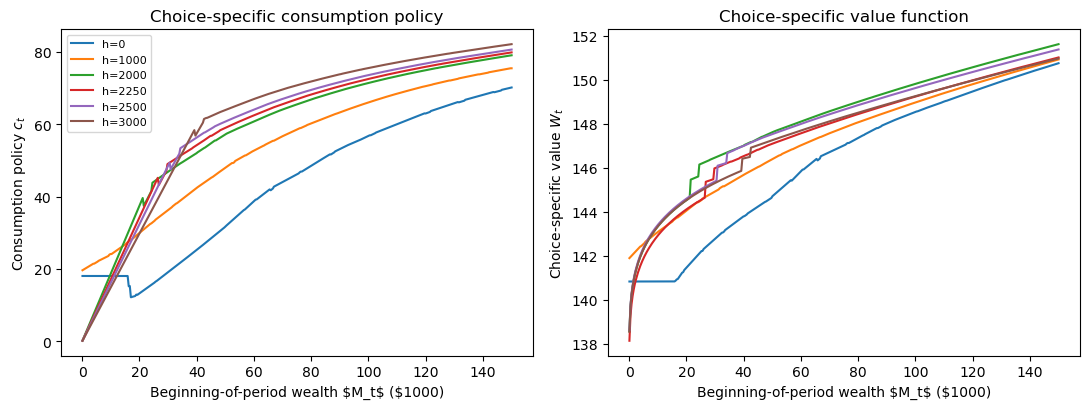

In [7]:
# Choice-specific consumption policy and value functions at age ~39
# (period 20), for a mid-experience, high-type worker. This is exactly the
# kind of picture Section 4 of the paper describes: combining a discrete
# choice with a continuous one creates kinks in the value function and
# discontinuities in the policy function, which is what DC-EGM's upper
# envelope step is built to resolve.
period_to_plot = 20
wealth_grid = jnp.linspace(0.1, 150.0, 400)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for choice in range(model_specs_hs["n_choices"]):
    states = {
        "period": jnp.full_like(wealth_grid, period_to_plot, dtype=int),
        "lagged_choice": jnp.zeros_like(wealth_grid, dtype=int),
        "high_type": jnp.ones_like(wealth_grid, dtype=int),
        "survival": jnp.ones_like(wealth_grid, dtype=int),
        "experience": jnp.full_like(wealth_grid, 0.5),
        "assets_begin_of_period": wealth_grid,
    }
    choices = jnp.full_like(wealth_grid, choice, dtype=int)
    policy, value = model_hs_solved.policy_and_value_for_states_and_choices(
        states=states, choices=choices
    )
    hours = int(model_specs_hs["hours_by_choice"][choice])
    axes[0].plot(wealth_grid, policy, label=f"h={hours}")
    axes[1].plot(wealth_grid, value, label=f"h={hours}")

axes[0].set_xlabel("Beginning-of-period wealth $M_t$ ($1000)")
axes[0].set_ylabel("Consumption policy $c_t$")
axes[0].set_title("Choice-specific consumption policy")
axes[1].set_xlabel("Beginning-of-period wealth $M_t$ ($1000)")
axes[1].set_ylabel("Choice-specific value $W_t$")
axes[1].set_title("Choice-specific value function")
axes[0].legend(fontsize=8)
fig.tight_layout()

## 5. Simulate all three education groups

We solve and simulate dropouts, high-school and college graduates
separately, drawing the unobserved type for each simulated agent from the
paper's estimated type shares (Table 7), and compare simulated life-cycle
profiles against the qualitative shapes in the paper's Figures 5-8: rising
then plateauing participation, a hump/monotonic rise in wealth, and a clear
jump in wealth at 65 from the superannuation lump sum. We are calibrating,
not re-estimating, so we should not expect to match levels — the paper's
own Figure 8 shows wealth around \$1M (college), \$500k (high school) and
\$400k (dropout) at age 70, using moments fit to HILDA.


In [8]:
N_AGENTS = 2000
all_sims = []

for education in EDUCATION_GROUPS:
    model, model_specs = build_model(education)
    params = build_params(education)
    model_solved = model.solve(params)

    high_type_share = MISC_PARAMS["high_type_share"][education]
    states_initial = {
        "period": jnp.zeros(N_AGENTS, dtype=int),
        "lagged_choice": jnp.zeros(N_AGENTS, dtype=int),
        "high_type": jnp.array(
            np.random.default_rng(0).binomial(1, high_type_share, N_AGENTS), dtype=int
        ),
        "survival": jnp.ones(N_AGENTS, dtype=int),
        "experience": jnp.zeros(N_AGENTS),
        "assets_begin_of_period": jnp.ones(N_AGENTS) * 2.0,
    }
    df = model_solved.simulate(states_initial=states_initial, seed=1)

    df["age"] = model_specs["t0"] + df.index.get_level_values("period")
    df["hours"] = np.array(model_specs["hours_by_choice"])[df["choice"].to_numpy()]
    df["education"] = education
    all_sims.append(df.reset_index())

sim_all = pd.concat(all_sims, ignore_index=True)

Starting state space creation
State space created.

Starting state-choice space creation and child state mapping.
State, state-choice and child state mapping created.

Start creating batches for the model.
The batch size of the backwards induction is  72
Model setup complete.



Starting state space creation
State space created.

Starting state-choice space creation and child state mapping.
State, state-choice and child state mapping created.

Start creating batches for the model.
The batch size of the backwards induction is  72
Model setup complete.



Starting state space creation
State space created.

Starting state-choice space creation and child state mapping.
State, state-choice and child state mapping created.

Start creating batches for the model.
The batch size of the backwards induction is  72
Model setup complete.



## 6. Policy experiment: eliminating the Age Pension

Section 9 of the paper studies what happens if the Age Pension is removed
entirely. We replicate the qualitative direction of that experiment for the
high-school group using the `pension_scale` toggle we built into the
budget constraint: without the means-tested safety net, agents have a
stronger incentive to self-insure through private saving (and, to a lesser
extent, by working more) near and after 65.

*Note:* we report **median** (not mean) wealth. A small share of simulated
paths under the no-pension counterfactual land in the sparsely-gridded tail
of the assets grid, where linear interpolation is numerically unstable and
produces implausible outliers; the median is robust to this and the
qualitative comparison is unaffected. A denser/wider grid in that region
would remove the artifact, at the cost of a slower solve.


## 7. Where this differs from the paper, and how to extend it

This notebook favors a fast, readable first pass over an exact
reproduction. The most consequential simplifications, all noted where they
occur above, are:

1. **Calibrated, not estimated.** We use the paper's published point
   estimates directly; no MSM estimation against HILDA is performed.
2. **Stationary policy regime.** The Age Pension and tax rules are held at
   their post-2010 values for the whole simulated cohort.
3. **Terminal bequest.** Both natural termination at 85 and death before it
   are valued by bequeathing 100% of terminal wealth, since dcegm's
   terminal-period solver assumes consumption equals full wealth. The
   paper's own terminal period (eq. 21-22) allows a genuine consumption/
   bequest trade-off even at the maximum age.
4. **Discounted bequest.** Because we implement mortality risk via dcegm's
   standard stochastic-survival pattern, the bequest term is discounted by
   $\beta$ once, unlike the undiscounted $(1-\delta_t)B(\cdot)$ term in
   eq. (12) of the paper.
5. **Modest grids.** `ASSETS_GRID`/`EXPERIENCE_GRID` above are sized to keep
   this notebook fast; a finer grid (particularly in the far tail of
   assets) would remove the numerical artifact noted in Section 6 and
   likely tighten the life-cycle profiles in Section 5.

None of these change the qualitative mechanism: a discrete hours choice
combined with continuous savings under a means-tested pension produces
exactly the kind of kinked, non-concave choice-specific value functions
that DC-EGM was built to solve (Section 4), and removing the pension safety
net raises private saving, as the paper's own policy experiment finds.
